# Der Dehnstab

<div style="border: 2px solid #4bb98c; padding: 15px; border-radius: 8px; background-color: #f0faf6; margin-bottom: 15px;">
    <h3 style="margin-top:0; color:#2d7a5c;">Lernziele</h3>
    <ol>
        <li><strong>Formfunktionen</strong> des 1D-Stabelements (linear) im Referenzelement ableiten und die <strong>isoparametrische Abbildung</strong> anwenden</li>
        <li>Die <strong>Elementsteifigkeitsmatrix</strong> herleiten: <em>k<sub>e</sub> = ∫ B<sup>T</sup> E A B dx</em> und integrieren</li>
        <li><strong>Elementlastvektoren</strong> für <em>Streckenlast n(x)</em> und <em>Randkraft F</em> formulieren</li>
        <li>Die <strong>globale Steifigkeitsmatrix</strong> und den <strong>globalen Lastvektor</strong> durch Assemblierung aufbauen</li>
        <li><strong>Randbedingungen</strong> (Dirichlet/Neumann) korrekt in das Gleichungssystem einarbeiten</li>
        <li>Das lineare Gleichungssystem lösen und <strong>Verschiebung u</strong>, <strong>Dehnung ε</strong> und <strong>Spannung σ</strong> auswerten</li>
        <li>Die Ergebnisse mit der <strong>analytischen Lösung</strong> vergleichen und die <strong>Konvergenz</strong> (h-Verfeinerung) beurteilen</li>
    </ol>
</div>


In diesem Notebook wird die FEM-Implementierung für den Dehnstab erläutert und erprobt.

![Stab.png](images/Stab.png)


Die Differentialgleichung des Dehnstabes lautet:

$$
 {EA} u^{\prime \prime} =  - {n(x)} \; ,
$$

Für diese Differentialgleichung haben wir in der Vorlesung die schwache Form hergeleitet:

$$
\textcolor{green}{\int_{0}^{\ell} \delta \epsilon\cdot E\epsilon\, A \text{ d}x } -\textcolor{red} {\int_0^{\ell} \delta u \cdot n \text{ d}x } - \textcolor{blue}{\delta u(\ell) \cdot F} = 0\; 
$$

## Das Finite Element

Ein Finites Element besteht in dem vorliegenden Beispiel aus 2 Knoten. Sowohl die Knoten, als auch die Elemente werden im Allgemeinen nummeriert, damit man sie eindeutig ansprechen kann. Im Bild sind die Elementnummern in den rechteckigen Kästen neben dem Element eingetragen. Die Knotennummer sind in den Kreisen neben den Knoten dargestellt. Die Knoten sind die Träger der primären Feldvariablen (hier: Verschiebung $u$) und Ziel der Finiten Elemente Berechnung ist die Bestimmung der primären Variablen, auch Freiheitsgrade (English: Degree of freedom **Dof**) an den Knoten. 

![Stabelement.png](images/Stab_element_02.png)

Auf diesen Elementen werden dann einfache Ansatzfunktionen verwendet, welche eine lineare Approximation des Verschiebungsfeldes darstellen:

\begin{align}
 N_1(\xi) & = (1-\xi) \qquad N_2(\xi)= \xi  \\
 u_h(\xi) & = N_1(\xi) \hat{u}_1^{(e)}+ N_2(\xi) \hat{u}_2^{(e)} \\
 u_h(\xi) & = \sum_{I=1}^2 N_I(\xi) \hat{u}_I^{(e)}
 \end{align}

In [1]:
import numpy as np
import plotly.graph_objects as go

# Define the x values
x = np.linspace(0, 1, 100)

N1 = 1-x
N2 = x

N = np.array([N1,N2])

# Create the figure
fig = go.Figure()
# Add traces for each shape function
fig.add_trace(go.Scatter(
    x=x,
    y=N1,
    mode='lines',
    name='N_1',
    line=dict(width=2)
))

fig.add_trace(go.Scatter(
    x=x,
    y=N2,
    mode='lines',
    name='N_2',
    line=dict(width=2)
))
# Update layout
fig.update_layout(
    xaxis_title="ξ",
    yaxis_title="N(ξ)",
    font=dict(family='serif', size=15),
    hovermode='x unified',
    plot_bgcolor='white',
    xaxis=dict(
        showgrid=True,
        gridwidth=1,
        gridcolor='lightgrey',
        zeroline=False
    ),
    yaxis=dict(
        showgrid=True,
        gridwidth=1,
        gridcolor='lightgrey',
        zeroline=False
    ),
    legend=dict(
        x=1.05,
        y=1,
        xanchor='left',
        yanchor='top'
    )
)
# Show the plot
fig.show()


### Beispiel für Interpolationion mit Formfunktionen

Am Knoten 1 liegt eine Verschiebung von $u_1=3$ mm vor und am Knoten 2 eine Verschiebung von $u_2=5$ mm. Die Verschiebung an der Stelle $\xi=0.5$ soll berechnet werden.

Die Verschiebung an der Stelle $\xi=0.5$ wird mit den Formfunktionen berechnet:

\begin{align*}
    u(\xi=0.5) &= N_1(\xi=0.5) \cdot u_1 + N_2(\xi=0.5) \cdot u_2 \\
    &= (1-0.5) \cdot 3 \text{ mm}+ 0.5 \cdot 5 \text{ mm}\\
    &= 1.5 + 2.5 \text{ mm}\\
    &= 4 \text{ mm}
\end{align*}

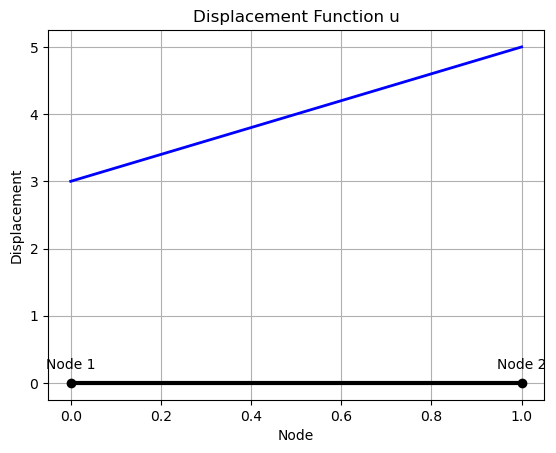

In [2]:
import matplotlib.pyplot as plt
import numpy as np
u_k = np.array([[3 , 5]]).T
u = N.T @ u_k

# Create the figure and axis and plot u
fig, ax = plt.subplots()
ax.plot(x,u, 'b-', linewidth=2)
plt.scatter([0, 1], [0,0], color='black', zorder=5)
plt.annotate('Node 1', (0, 0), textcoords="offset points", xytext=(0,10), ha='center')
plt.annotate('Node 2', (1, 0), textcoords="offset points", xytext=(0,10), ha='center')
plt.plot([0, 1], [0,0], 'k-', linewidth=3)
plt.xlabel('Node')
plt.ylabel('Displacement')
plt.title('Displacement Function u')
plt.grid(True)
plt.show()


## Die Steifigkeitsmatmatrix des Dehnstabes

Analog zum Verfahren von Ritz wird jetzt der Ansatz für $u$ und $\delta u$ sowie für $\varepsilon$ und $\delta \varepsilon$ aufgestellt.


In [3]:
import sympy as sp
from IPython.display import display, Math, Latex

# Freie Variable
xi = sp.symbols('xi')
x  = sp.symbols('x')

# ============================================================
#  PARAMETER: Anzahl der Knoten pro Element
# ============================================================
num_par = 2


N1 = 1-xi
N2 = xi

N=sp.Matrix([N1,N2])

# Unbekannte Koeffizienten a_i
ulist = [sp.Symbol(f'u_{i}') for i in range(num_par)]
u_i = sp.Matrix(ulist)

# Verschiebungsansatz u_h(x)
u_h = N.T @ u_i

u_h 

Matrix([[u_0*(1 - xi) + u_1*xi]])

In [4]:
# Virtuelle Koeffizienten delta_u_i
dulist = [sp.Symbol(rf'\delta u_{i}') for i in range(num_par)]
du = sp.Matrix(dulist)

# Virtuelle Verschiebung delta_u(x)
delta_u = N.T @ du
delta_u


Matrix([[\delta u_0*(1 - xi) + \delta u_1*xi]])

### Ableitungen bilden

Für die schwache Form benötigen wir die **Dehnungen**:

$$
\varepsilon = \frac{\mathrm{d} u_h}{\mathrm{d} x}=\frac{\mathrm{d} u_h}{\mathrm{d} \xi}\frac{\mathrm{d} \xi}{\mathrm{d} \xi}, \qquad
\delta\varepsilon = \frac{\mathrm{d} \,\delta u}{\mathrm{d} \xi}\frac{\mathrm{d} \xi}{\mathrm{d} \xi}
$$

In [5]:
ell_e = sp.symbols("ell_e")
epsilon = sp.diff(u_h, xi)*1/ell_e
delta_epsilon = sp.diff(delta_u, xi)*1/ell_e

display(Math(r'\varepsilon(x) = ' + sp.latex(epsilon)))
display(Math(r'\delta\varepsilon(x) = ' + sp.latex(delta_epsilon)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
N.diff(xi).T @ u_i  /ell_e

Matrix([[(-u_0 + u_1)/ell_e]])

## 3. Einsetzen in die schwache Form

Nun setzen wir die Ansätze in die drei Terme der schwachen Form ein.

Wir definieren zunächst die **symbolischen Materialparameter**:

In [7]:
# Symbolische Parameter (werden erst später durch Zahlenwerte ersetzt)
E_s, A_s, F_s, n_s, ell = sp.symbols('E A F n ell')

### Term 1: Innere virtuelle Arbeit (Formänderungsarbeit)

\begin{align}
W_{\text{int}}  & = \int_0^{\ell} \delta\varepsilon \cdot E \, A \cdot \varepsilon \; \mathrm{d}x \\
&= \int_0^{1} \delta\varepsilon \cdot E \, A \cdot \varepsilon \; \mathrm{d}\xi \, \ell_e 
\end{align}

In [8]:
import sympy as sp
xi,ell,E,A = sp.symbols('xi, ell,E,A')

# Ableitungen der Formfunktionen
dNdxi = sp.diff(N,xi)

# Steifigkeitsmatrix
Kmat = sp.integrate(dNdxi*dNdxi.T,(xi,0,1))*E*A/ell 
Kmat

W_int = sp.simplify(
    sp.integrate(
        delta_epsilon * E_s * A_s * epsilon
        , (xi, 0, 1))
    )*ell_e

### Term 2: Virtuelle Arbeit der Einzelkraft

$$
W_F = \delta u(\ell) \cdot F
$$

In [9]:
W_F = delta_u.subs(xi, 1) * F_s

display(Math(r'W_F = ' + sp.latex(W_F)))

<IPython.core.display.Math object>

### Term 3: Virtuelle Arbeit der Streckenlast

\begin{align}
W_n & = \int_0^{\ell} \delta u \cdot n \; \mathrm{d}x \\
    & = \int_0^{1} \delta u \cdot n \; \mathrm{d}\xi \ell_e
\end{align}



In [10]:
W_n = sp.simplify(
    sp.integrate(
        delta_u * n_s,
        (xi, 0, 1))*ell_e
    )

display(Math(r'W_n = ' + sp.latex(W_n)))

<IPython.core.display.Math object>

### Schwache Form zusammensetzen

$$
W_{\text{int}} - W_F - W_n = 0
$$

In [11]:
schwache_Form = sp.Eq((W_int  - W_n)[0], 0)

display(schwache_Form)

Eq(A*E*(\delta u_0 - \delta u_1)*(u_0 - u_1)/ell_e - ell_e*n*(\delta u_0 + \delta u_1)/2, 0)

## 4. Gleichungssystem aufstellen

<div style="border-left: 4px solid #5bc0de; padding: 10px; background-color: #eef7fb; margin: 10px 0;">

<strong>Schlüsselidee:</strong> 
Die schwache Form muss für <em>beliebige</em> virtuelle Verschiebungen $\delta u_i$ gelten. Daraus folgt, dass alle Koeffizienten der $\delta u_i$ einzeln null sein müssen.

Daher können wir die Gleichung nach den $\delta u_i$ „sortieren" und erhalten ein <strong>lineares Gleichungssystem</strong>:

$$\mathbf{K} \cdot \mathbf{u} = \mathbf{f}$$

mit der <strong>Steifigkeitsmatrix</strong> $\mathbf{K}$ und dem <strong>Lastvektor</strong> $\mathbf{f}$.
</div>

Die Einträge werden durch Koeffizientenvergleich extrahiert:

$$
K_{ij} = \frac{\partial^2 (\text{schwache Form})}{\partial\, \delta u_i \;\partial\, u_j}
\qquad\text{und}\qquad
f_i = -\frac{\partial (\text{schwache Form})}{\partial\, \delta u_i}\bigg|_{\mathbf{u}=\mathbf{0}}
$$

In [12]:
n_eq = len(dulist)  # Anzahl Gleichungen
m_eq = len(ulist)   # Anzahl Unbekannte

# Steifigkeitsmatrix K
K_e = sp.zeros(n_eq, m_eq)
# Lastvektor f
f_e = sp.zeros(m_eq, 1)

for i in range(n_eq):
    for j in range(m_eq):
        K_e[i, j] = sp.diff(schwache_Form.lhs, dulist[i], ulist[j])
    # Lastvektor: Terme ohne a_j (mit negativem Vorzeichen, da nach rechts gebracht)
    f_e[i, 0] = -schwache_Form.lhs.subs({ulist[j]: 0 for j in range(m_eq)}).diff(dulist[i])

print("Steifigkeitsmatrix K:")
display(K_e)
print("\nLastvektor f:")
display(f_e)

Steifigkeitsmatrix K:


Matrix([
[ A*E/ell_e, -A*E/ell_e],
[-A*E/ell_e,  A*E/ell_e]])


Lastvektor f:


Matrix([
[ell_e*n/2],
[ell_e*n/2]])

Bei der Steifigkeitsmatrix werden die Materialkonstanten und die Geometrie meist ausgeklammert:

$$
\boldsymbol{K}=\frac{E A}{\ell_e}
\begin{bmatrix}
 1 & -1 \\
 -1 & 1
\end{bmatrix}
$$

Die hier hergeleitete Steifigkeitsmatrix und Lastvektor ist nur für ein Element gültig.ig. Für mehrere Elemente muss die Steifigkeitsmatrix und der Lastvektor für jedes Element berechnet und dann zu einer globalen Steifigkeitsmatrix und einem globalen Lastvektor zusammengesetzt werden (**Assemblierung**)

### 2) Assemblierung für zwei Elemente

Wir betrachten drei Knoten (1–2–3) und zwei gleich lange Elemente (1: Knoten 1–2, 2: Knoten 2–3) mit $\ell_1 = \ell_2 = \ell/2$.

- Randbedingungen: u(0) = 0 am Knoten 1 (Dirichlet), äußere Einzelkraft F am Knoten 3 (Neumann)
- Rechte Seite: Streckenlast n über die gesamte Länge sowie F am letzten Knoten

In [53]:
# Before assemblierung, set element length to ell/2
K_e = K_e.subs(ell_e, ell/2)
f_e = f_e.subs(ell_e, ell/2)

# Erstelle eine 3x3 Matrix mit Nullen
K = sp.Matrix([[0, 0, 0], [0, 0, 0], [0, 0, 0]])

f = sp.Matrix([0, 0, 0])

# Assemblierung Element 1 (Knoten 1-2)

K[0:2,0:2] += K_e
for i in range(0,2):
    f[i] += f_e[i]

# # Assemblierung Element 2 (Knoten 2-3)

K[1:3,1:3] += K_e
for i in range(1,3):
    f[i] += f_e[i-1]

f[2] += F_s

In [54]:
K

Matrix([
[ 2*A*E/ell, -2*A*E/ell,          0],
[-2*A*E/ell,  4*A*E/ell, -2*A*E/ell],
[         0, -2*A*E/ell,  2*A*E/ell]])

In [55]:
f

Matrix([
[    ell*n/4],
[    ell*n/2],
[F + ell*n/4]])